In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

In [44]:
df = pd.read_csv('healthcare-2016.csv')
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


# Display the first few rows

In [45]:
print(df.head())

      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4  8.841186e+12        5642494      F  2016-04-29T16:07:23Z   

         AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0   
4  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             1   

   Diabetes  Alcoholism  Handcap  SMS_received No-show  
0         0           0        0             0      No  
1         0           0        0      

# Check basic information

In [46]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB
None


# Check for missing values

In [47]:
print(df.isnull().sum())

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


# Convert date columns to datetime

In [48]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Rename columns to match df.info() output

In [49]:
df.rename(columns={
    'No-show': 'No_show',
    'Hipertension': 'Hypertension',
    'Handcap': 'Handicap'
}, inplace=True)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110527 non-null  float64            
 1   AppointmentID   110527 non-null  int64              
 2   Gender          110527 non-null  object             
 3   ScheduledDay    110527 non-null  datetime64[ns, UTC]
 4   AppointmentDay  110527 non-null  datetime64[ns, UTC]
 5   Age             110527 non-null  int64              
 6   Neighbourhood   110527 non-null  object             
 7   Scholarship     110527 non-null  int64              
 8   Hypertension    110527 non-null  int64              
 9   Diabetes        110527 non-null  int64              
 10  Alcoholism      110527 non-null  int64              
 11  Handicap        110527 non-null  int64              
 12  SMS_received    110527 non-null  int64              
 13  No_show       

# No-show rate

In [50]:
no_show_rate = df['No_show'].value_counts(normalize=True) * 100
print(no_show_rate)

No_show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64


# Visualize no-show rate

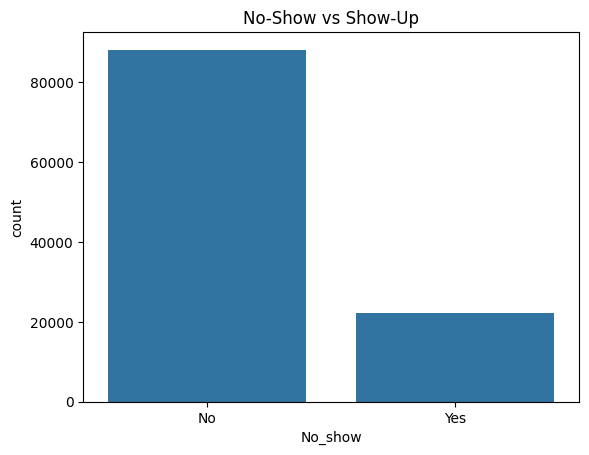

In [51]:
sns.countplot(x='No_show', data=df)
plt.title('No-Show vs Show-Up')
plt.show()

# Gender distribution

In [52]:
gender_distribution = df['Gender'].value_counts(normalize=True) * 100
print(gender_distribution)


Gender
F    64.997693
M    35.002307
Name: proportion, dtype: float64


# No-show rate by gender

In [53]:
no_show_by_gender = df.groupby('Gender')['No_show'].value_counts(normalize=True) * 100
print(no_show_by_gender)

Gender  No_show
F       No         79.685412
        Yes        20.314588
M       No         80.032052
        Yes        19.967948
Name: proportion, dtype: float64


# Visualize no-show rate by gender

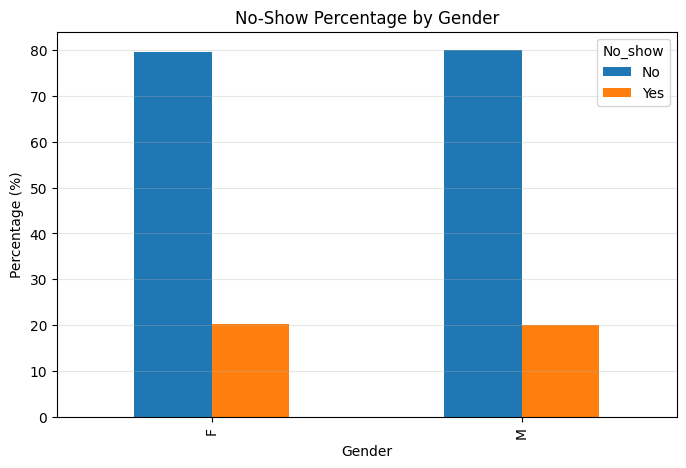

In [54]:
gender_rate = pd.crosstab(
    df['Gender'],
    df['No_show'],
    normalize='index'
) * 100

gender_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('No-Show Percentage by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage (%)')
plt.legend(title='No_show')
plt.grid(axis='y', alpha=0.3)

plt.show()

# Age distribution

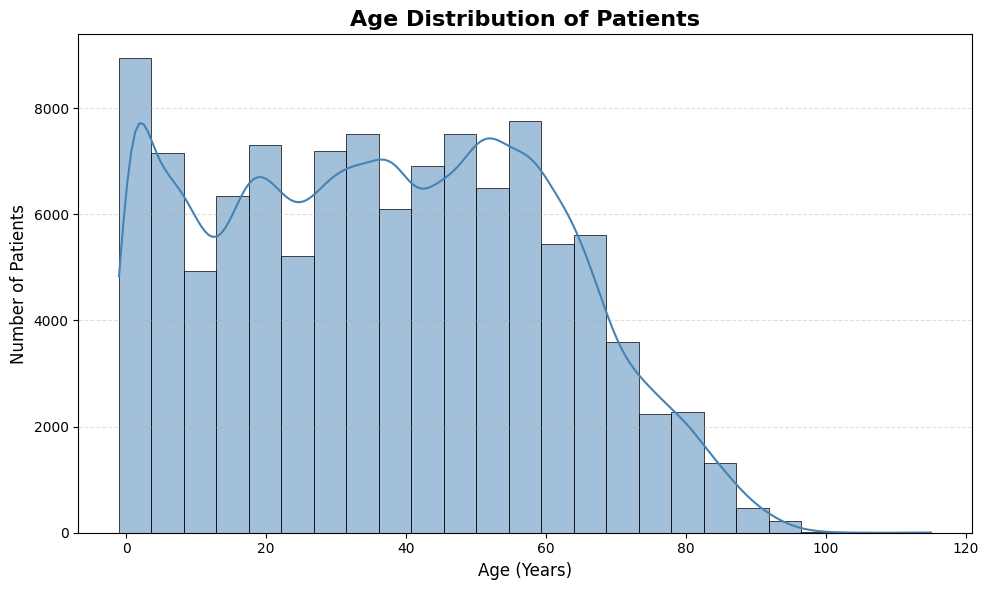

In [55]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Age'],
    bins=25,
    kde=True,
    color='steelblue',
    edgecolor='black',
    linewidth=0.5
)

plt.title('Age Distribution of Patients',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

# No-show rate by age group

In [56]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 18, 35, 50, 65, 100], labels=['0-18', '19-35', '36-50', '51-65', '66+'])
no_show_by_age = df.groupby('AgeGroup')['No_show'].value_counts(normalize=True) * 100
print(no_show_by_age)

AgeGroup  No_show
0-18      No         77.462787
          Yes        22.537213
19-35     No         76.165224
          Yes        23.834776
36-50     No         79.674208
          Yes        20.325792
51-65     No         83.450863
          Yes        16.549137
66+       No         84.481721
          Yes        15.518279
Name: proportion, dtype: float64


C:\Users\dell\AppData\Local\Temp\ipykernel_3484\3983366588.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  no_show_by_age = df.groupby('AgeGroup')['No_show'].value_counts(normalize=True) * 100


# Visualize no-show rate by age group

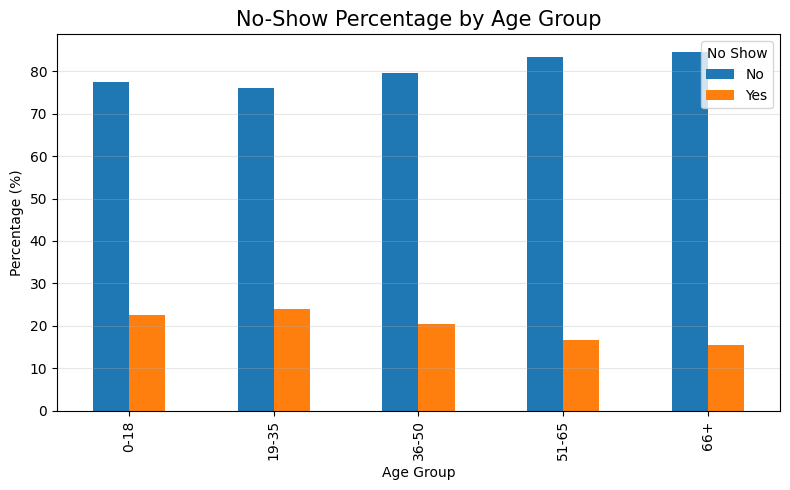

In [57]:
age_rate = (
    pd.crosstab(df['AgeGroup'], df['No_show'], normalize='index') * 100
)

age_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('No-Show Percentage by Age Group', fontsize=15)
plt.xlabel('Age Group')
plt.ylabel('Percentage (%)')
plt.legend(title='No Show')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

# 4.4 Most common neighborhoods for appointments

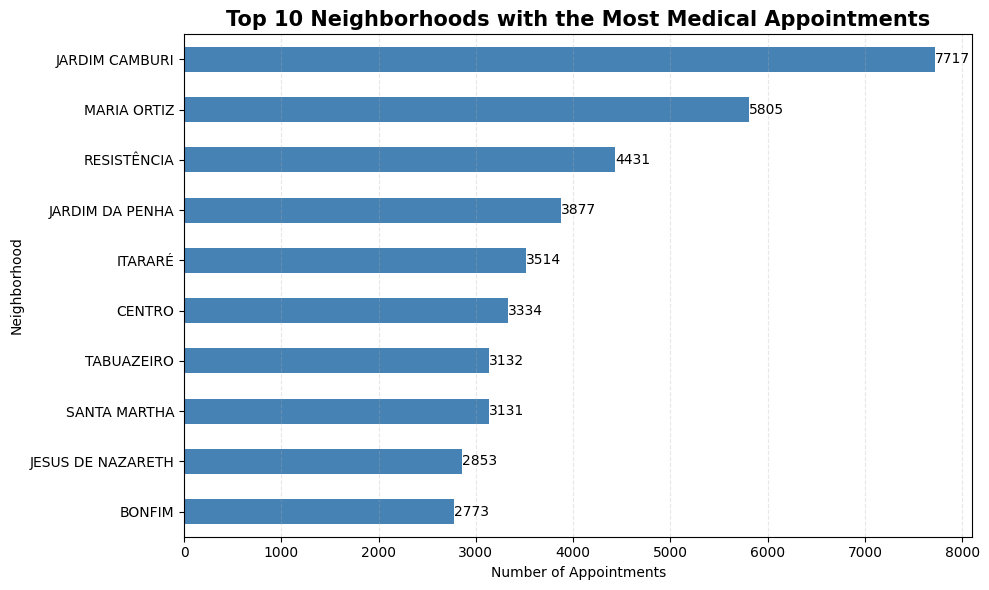

In [58]:
plt.figure(figsize=(10,6))

neighborhood_counts = df['Neighbourhood'].value_counts().head(10)

ax = neighborhood_counts.sort_values().plot(
    kind='barh',
    color='steelblue'
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title('Top 10 Neighborhoods with the Most Medical Appointments',
          fontsize=15,
          fontweight='bold')

plt.xlabel('Number of Appointments')
plt.ylabel('Neighborhood')

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

# Distribution of appointment dates

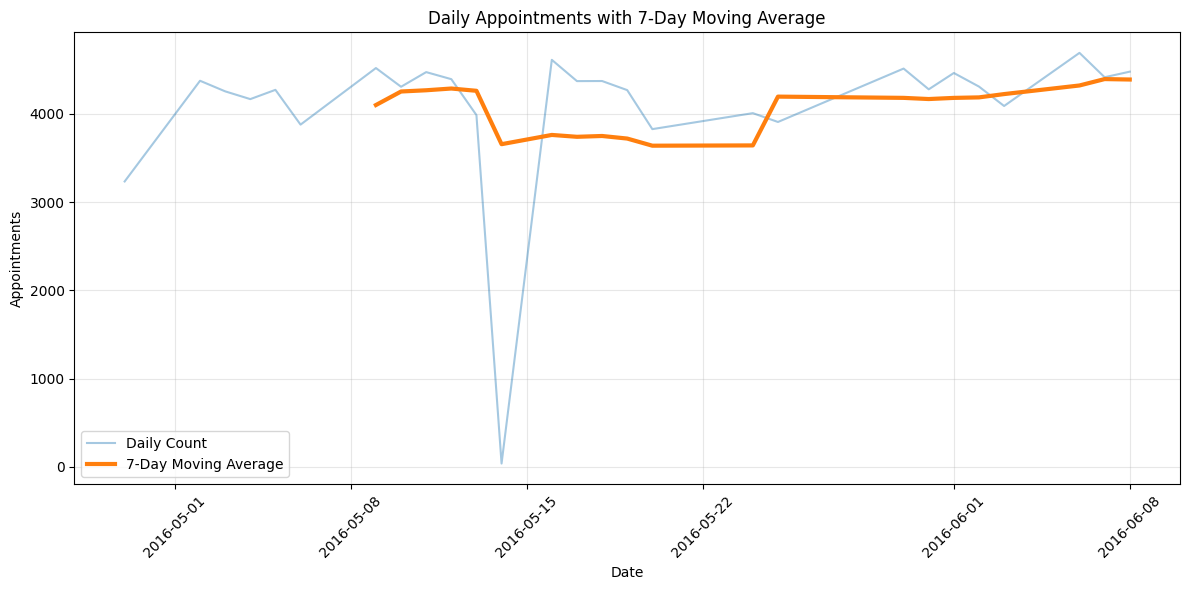

In [59]:
daily_counts = (
    df['AppointmentDay']
    .dt.date
    .value_counts()
    .sort_index()
)

rolling = daily_counts.rolling(7).mean()

plt.figure(figsize=(12,6))

plt.plot(daily_counts.index,
         daily_counts.values,
         alpha=0.4,
         label='Daily Count')

plt.plot(rolling.index,
         rolling.values,
         linewidth=3,
         label='7-Day Moving Average')

plt.title('Daily Appointments with 7-Day Moving Average')

plt.xlabel('Date')
plt.ylabel('Appointments')

plt.legend()

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# How far in advance are appointments scheduled?

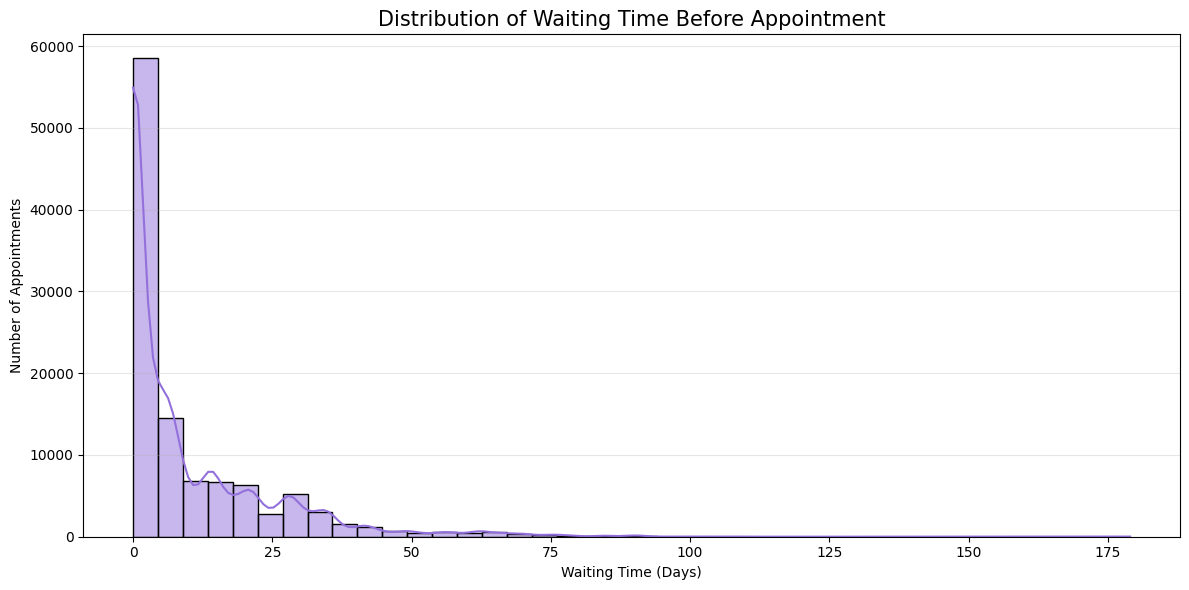

In [60]:
# Convert columns to datetime
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Create waiting time column
df['Days_Between'] = (
    df['AppointmentDay'].dt.normalize() -
    df['ScheduledDay'].dt.normalize()
).dt.days

# Keep only valid waiting times
waiting = df[df['Days_Between'] >= 0]

# Plot
plt.figure(figsize=(12,6))

sns.histplot(
    waiting['Days_Between'],
    bins=40,
    kde=True,
    color='mediumpurple',
    edgecolor='black'
)

plt.title('Distribution of Waiting Time Before Appointment', fontsize=15)
plt.xlabel('Waiting Time (Days)')
plt.ylabel('Number of Appointments')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

# No-show rates based on scheduling in advance

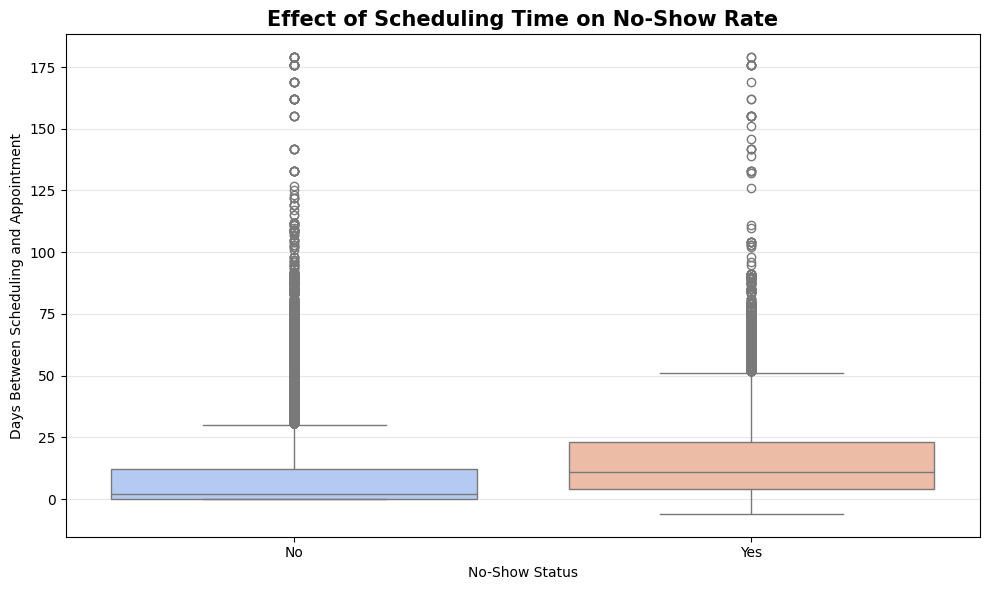

In [61]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='No_show',
    y='Days_Between',
    hue='No_show',
    data=df,
    palette='coolwarm',
    legend=False
)

plt.title('Effect of Scheduling Time on No-Show Rate',
          fontsize=15,
          fontweight='bold')

plt.xlabel('No-Show Status')
plt.ylabel('Days Between Scheduling and Appointment')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

# no-show rate by handicap status

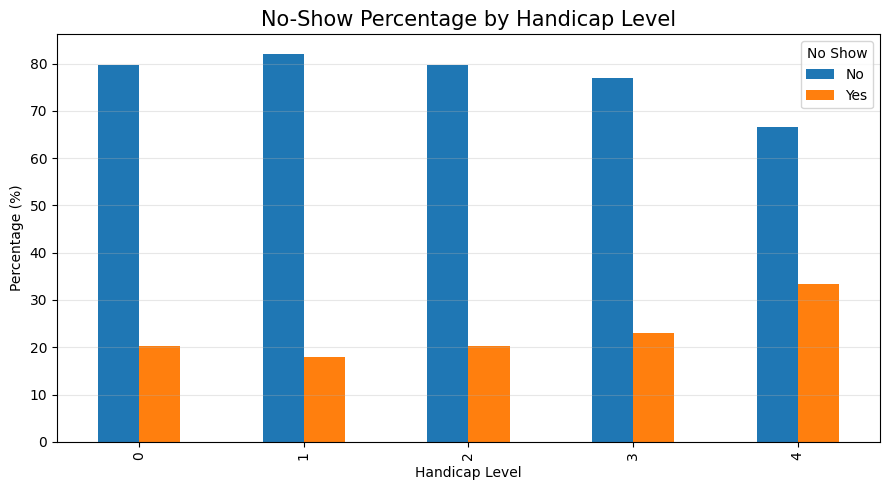

In [62]:
handicap_rate = (
    pd.crosstab(df['Handicap'], df['No_show'], normalize='index') * 100
)

handicap_rate.plot(
    kind='bar',
    figsize=(9,5)
)

plt.title('No-Show Percentage by Handicap Level', fontsize=15)
plt.xlabel('Handicap Level')
plt.ylabel('Percentage (%)')

plt.legend(title='No Show')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Subplots: No-show rate by age group and gender

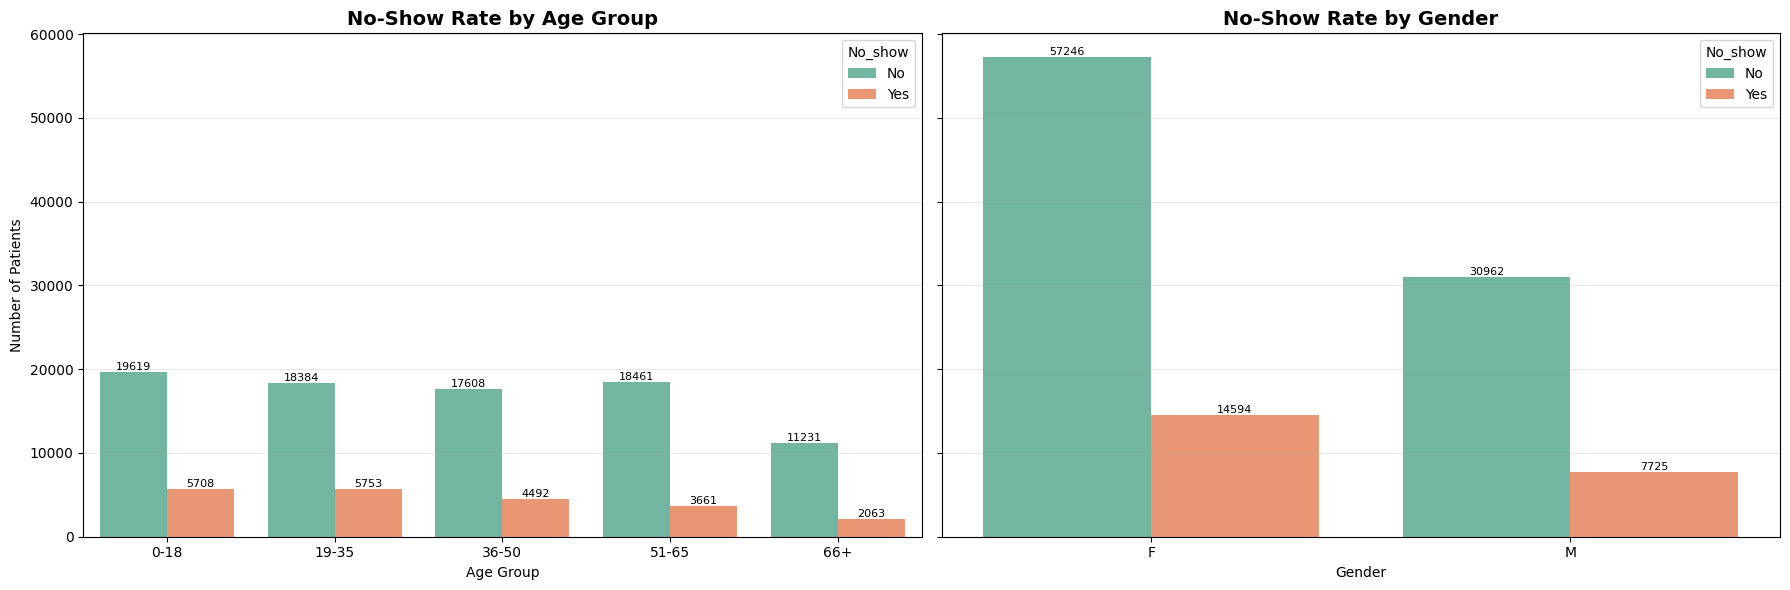

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(18,6), sharey=True)

# Age Group
sns.countplot(
    x='AgeGroup',
    hue='No_show',
    data=df,
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title('No-Show Rate by Age Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Patients')
axes[0].grid(axis='y', alpha=0.3)

# Gender
sns.countplot(
    x='Gender',
    hue='No_show',
    data=df,
    palette='Set2',
    ax=axes[1]
)

axes[1].set_title('No-Show Rate by Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('')
axes[1].grid(axis='y', alpha=0.3)

# Add count labels
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

plt.tight_layout()
plt.show()

# Heatmap Correlation Heatmap

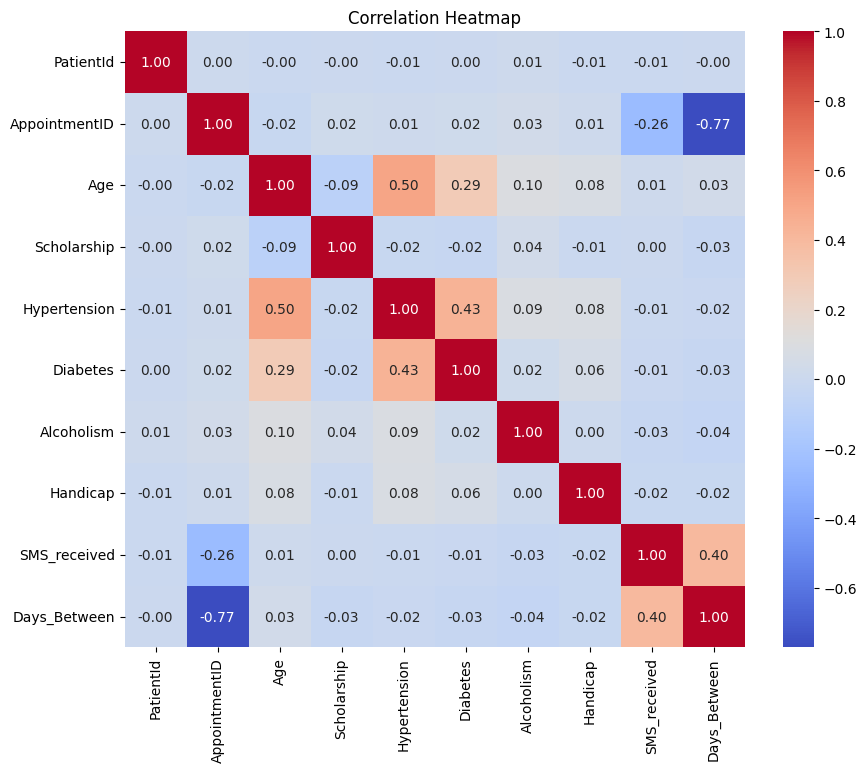

In [64]:
plt.figure(figsize=(10, 8))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

# Piechart No-Show Distribution

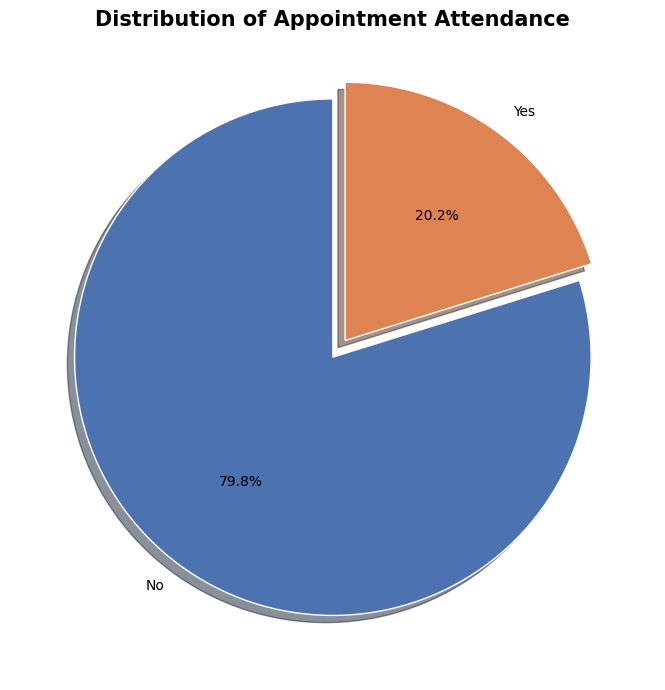

In [65]:
no_show_counts = df['No_show'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    no_show_counts,
    labels=no_show_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452'],
    explode=(0, 0.08),
    shadow=True,
    wedgeprops={'edgecolor':'white', 'linewidth':1}
)

plt.title('Distribution of Appointment Attendance', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()